In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.0 MB/s eta 0:00:00


In [3]:
!mkdir -p ~/.kaggle
!echo 'KGAT_1c0ac684cf036574a957baba28e37915' > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

!pip install kagglehub -q
import kagglehub
path = kagglehub.dataset_download("banuprasadb/visdrone-dataset")
print("Downloaded to:", path)

Using Colab cache for faster access to the 'visdrone-dataset' dataset.
Downloaded to: /kaggle/input/visdrone-dataset


In [4]:
import os

# Find where kagglehub saved it
print(path)  # from previous step

# List the folder contents
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show 2 levels deep
        for file in files[:3]:  # show first 3 files
            print(f'{indent}  {file}')

/kaggle/input/visdrone-dataset
visdrone-dataset/
  VisDrone_Dataset/
    visdrone.yaml
    VisDrone2019-DET-test-challenge/
      images/
    VisDrone2019-DET-test-dev/
      labels/
      images/
    VisDrone2019-DET-train/
      labels/
      images/
    VisDrone2019-DET-val/
      labels/
      images/


In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob

# Find image and label folders
image_files = glob.glob(path + '/**/images/**/*.jpg', recursive=True)
label_files = glob.glob(path + '/**/labels/**/*.txt', recursive=True)

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")

Total images: 10209
Total labels: 8629


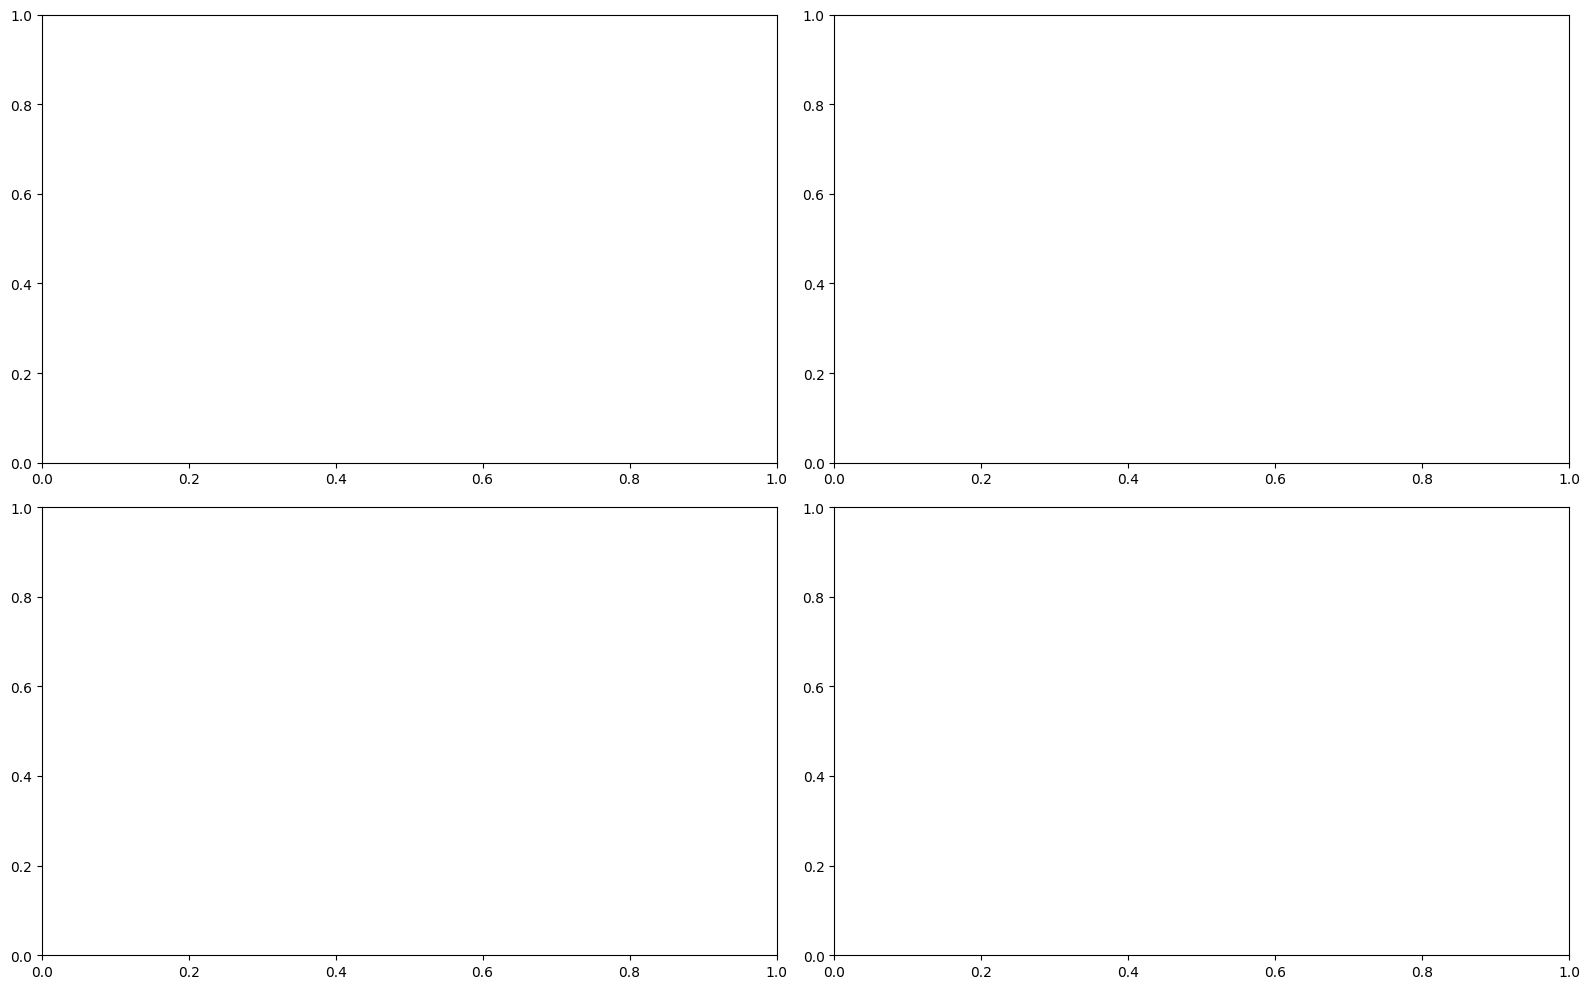

In [6]:
# Class names (VisDrone YOLO format)
CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']

COLORS = {
    0: (0, 255, 0),    # pedestrian - green
    1: (0, 200, 0),    # people - green
    3: (255, 0, 0),    # car - red
    4: (200, 0, 0),    # van - red
}

def visualize_sample(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    with open(label_path, 'r') as f:
        lines = f.readlines()

    human_count = 0
    car_count = 0

    for line in lines:
        parts = line.strip().split()
        cls = int(parts[0])
        x_c, y_c, bw, bh = map(float, parts[1:5])

        # Convert YOLO → pixel coords
        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)

        color = COLORS.get(cls, (255, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        if cls in [0, 1]: human_count += 1
        if cls in [3, 4]: car_count += 1

    # Add count overlay
    cv2.putText(img, f'Humans: {human_count}  Cars: {car_count}',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2)

    return img

# Show 4 sample images
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i in range(4):
    img_path = image_files[i]
    # Find matching label
    label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

    if os.path.exists(label_path):
        img = visualize_sample(img_path, label_path)
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f'Sample {i+1}')

plt.tight_layout()
plt.savefig('sample_visualizations.png', dpi=150)
plt.show()

In [7]:
from collections import Counter

all_classes = []

for label_file in label_files[:1000]:  # sample 1000 files
    with open(label_file, 'r') as f:
        for line in f.readlines():
            cls = int(line.strip().split()[0])
            all_classes.append(cls)

counts = Counter(all_classes)
print("Class distribution:")
for cls, count in sorted(counts.items()):
    print(f"  {CLASS_NAMES[cls]}: {count}")

Class distribution:
  pedestrian: 13656
  people: 3776
  bicycle: 847
  car: 17371
  van: 3471
  truck: 1665
  tricycle: 300
  awning-tricycle: 390
  bus: 1753
  motor: 3445


In [8]:
# Check one image and its expected label path
img_path = image_files[0]
label_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')

print("Image path:", img_path)
print("Expected label path:", label_path)
print("Label exists?", os.path.exists(label_path))

Image path: /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000208.jpg
Expected label path: /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge/labels/9999939_00000_d_0000208.txt
Label exists? False


In [9]:
import glob

all_labels = glob.glob(path + '/**/*.txt', recursive=True)
print("Total labels found:", len(all_labels))
print("\nSample label paths:")
for l in all_labels[:5]:
    print(l)

Total labels found: 8629

Sample label paths:
/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels/9999952_00000_d_0000200.txt
/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels/0000011_01350_d_0000003.txt
/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels/9999938_00000_d_0000253.txt
/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels/9999938_00000_d_0000019.txt
/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels/0000074_11362_d_0000022.txt


In [10]:
import os
import cv2
import matplotlib.pyplot as plt
import glob

# Get correct paths
base = '/kaggle/input/visdrone-dataset/VisDrone_Dataset'

# Find all images and labels
image_files = glob.glob(base + '/**/images/*.jpg', recursive=True)
label_files = glob.glob(base + '/**/labels/*.txt', recursive=True)

print(f"Total images: {len(image_files)}")
print(f"Total labels: {len(label_files)}")
print("\nSample image path:", image_files[0])

Total images: 10209
Total labels: 8629

Sample image path: /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge/images/9999939_00000_d_0000208.jpg


In [ ]:
CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']

COLORS = {
    0: (0, 255, 0),
    1: (0, 200, 0),
    3: (255, 0, 0),
    4: (200, 0, 0),
}

def visualize_sample(img_path):
    
    label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    if not os.path.exists(label_path):
        print(f"Label not found: {label_path}")
        return img  # return image without boxes

    with open(label_path, 'r') as f:
        lines = f.readlines()

    human_count = 0
    car_count = 0

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls = int(parts[0])
        x_c, y_c, bw, bh = map(float, parts[1:5])

        x1 = int((x_c - bw/2) * w)
        y1 = int((y_c - bh/2) * h)
        x2 = int((x_c + bw/2) * w)
        y2 = int((y_c + bh/2) * h)

        color = COLORS.get(cls, (255, 255, 0))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        if cls in [0, 1]: human_count += 1
        if cls in [3, 4]: car_count += 1

    cv2.putText(img, f'Humans: {human_count}  Cars: {car_count}',
                (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 3)

    return img


fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

shown = 0
for img_path in image_files:
    if shown >= 4:
        break
    img = visualize_sample(img_path)
    if img is not None:
        axes[shown].imshow(img)
        axes[shown].axis('off')
        axes[shown].set_title(f'Sample {shown+1}')
        shown += 1

plt.tight_layout()
plt.savefig('sample_visualizations.png', dpi=150)
plt.show()
print(f"Showed {shown} images")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

train_base = '/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train'

image_files = glob.glob(train_base + '/images/*.jpg')
label_files = glob.glob(train_base + '/labels/*.txt')

print(f"Train images: {len(image_files)}")
print(f"Train labels: {len(label_files)}")

# Verify one match
print("\nImage:", image_files[0])
print("Label:", image_files[0].replace('/images/', '/labels/').replace('.jpg', '.txt'))
print("Label exists?", os.path.exists(image_files[0].replace('/images/', '/labels/').replace('.jpg', '.txt')))

Train images: 6471
Train labels: 6471

Image: /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train/images/9999951_00000_d_0000023.jpg
Label: /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train/labels/9999951_00000_d_0000023.txt
Label exists? True


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

shown = 0
for img_path in image_files:
    if shown >= 4:
        break
    img = visualize_sample(img_path)
    if img is not None:
        axes[shown].imshow(img)
        axes[shown].axis('off')
        axes[shown].set_title(f'Sample {shown+1}')
        shown += 1

plt.tight_layout()
plt.savefig('sample_visualizations.png', dpi=150)
plt.show()
print(f"Showed {shown} images")

Output hidden; open in https://colab.research.google.com to view.

In [14]:
from collections import Counter
import glob

CLASS_NAMES = ['pedestrian', 'people', 'bicycle', 'car', 'van',
               'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']

all_classes = []
total_objects = 0

for label_file in label_files:
    with open(label_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 1:
                all_classes.append(int(parts[0]))
                total_objects += 1

counts = Counter(all_classes)
print(f"Total images: {len(image_files)}")
print(f"Total annotated objects: {total_objects}")
print("\nClass distribution:")
for cls, count in sorted(counts.items()):
    print(f"  {CLASS_NAMES[cls]}: {count} ({count/total_objects*100:.1f}%)")

Total images: 6471
Total annotated objects: 343205

Class distribution:
  pedestrian: 79337 (23.1%)
  people: 27059 (7.9%)
  bicycle: 10480 (3.1%)
  car: 144867 (42.2%)
  van: 24956 (7.3%)
  truck: 12875 (3.8%)
  tricycle: 4812 (1.4%)
  awning-tricycle: 3246 (0.9%)
  bus: 5926 (1.7%)
  motor: 29647 (8.6%)


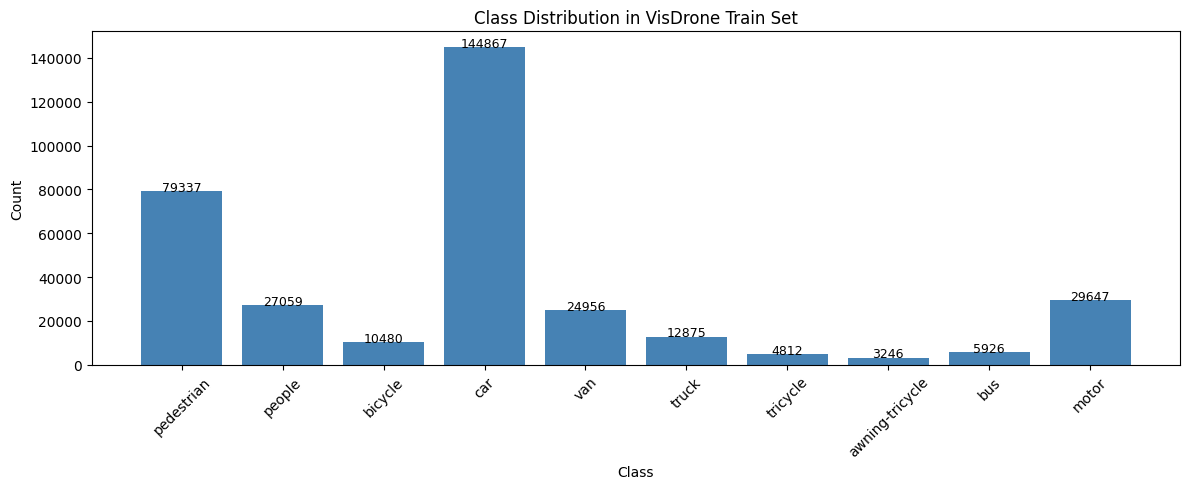

In [15]:
import matplotlib.pyplot as plt
import numpy as np

classes = [CLASS_NAMES[k] for k in sorted(counts.keys())]
values = [counts[k] for k in sorted(counts.keys())]

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, values, color='steelblue')
plt.title('Class Distribution in VisDrone Train Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

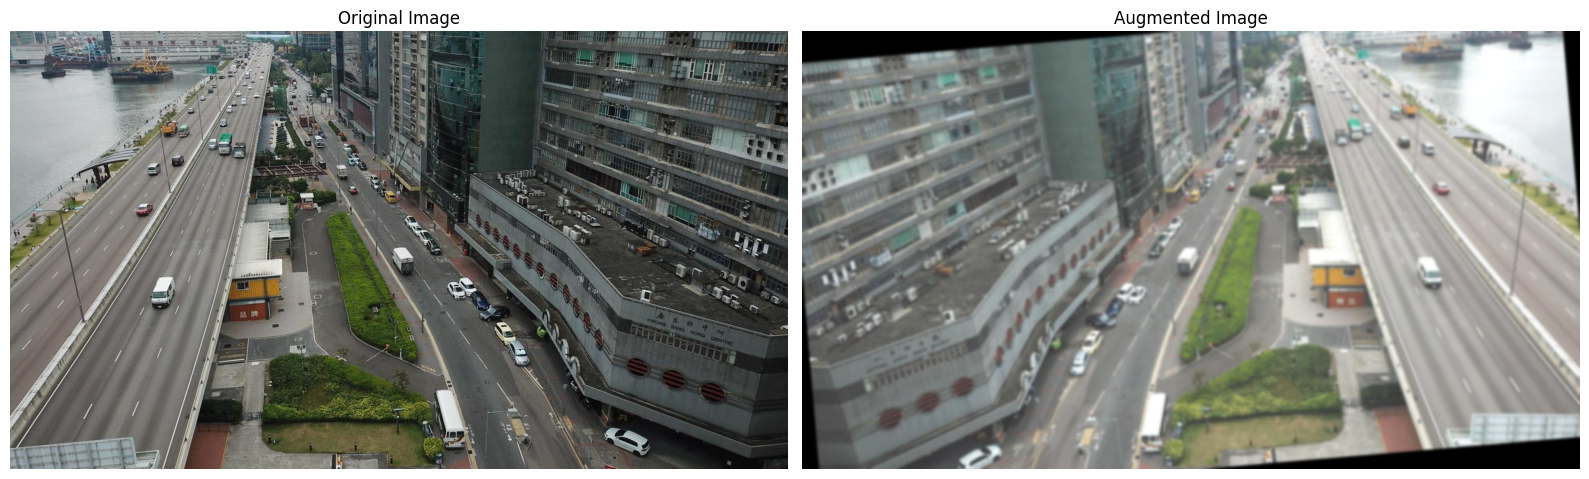

In [16]:
!pip install albumentations -q
import albumentations as A
import cv2, matplotlib.pyplot as plt

transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(p=1.0),
    A.Rotate(limit=15, p=1.0),
    A.GaussianBlur(p=1.0),
], bbox_params=A.BboxParams(format='yolo', label_fields=['labels']))

# Load one image and label
img_path = image_files[0]
label_path = img_path.replace('/images/', '/labels/').replace('.jpg', '.txt')

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

bboxes, labels = [], []
with open(label_path, 'r') as f:
    for line in f.readlines():
        parts = line.strip().split()
        if len(parts) >= 5:
            labels.append(int(parts[0]))
            bboxes.append(list(map(float, parts[1:5])))

# Apply augmentation
augmented = transform(image=img, bboxes=bboxes, labels=labels)

# Show original vs augmented
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img)
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(augmented['image'])
axes[1].set_title('Augmented Image')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150)
plt.show()

In [17]:
import yaml
import os

# Define the absolute path to your dataset in Colab
# Update this base_path to match where you unzipped the VisDrone dataset!
base_path = '/content/VisDrone_Dataset'

data_yaml = {
    'path': base_path,
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    # VisDrone classes. Note: 'pedestrian' (0), 'people' (1), and 'car' (3) are our targets.
    'names': ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
}

yaml_path = 'custom_visdrone.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"Created {yaml_path} successfully!")

Created custom_visdrone.yaml successfully!


In [18]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 Nano model
model = YOLO('yolov8n.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:
import yaml

# IMPORTANT: Make sure this base_path points to where your VisDrone dataset is actually located!
# For example, if it's in your Kaggle input folder, it might be: '/kaggle/input/visdrone-dataset/VisDrone_Dataset'
# If you unzipped it in Colab's default directory, it might be: '/content/VisDrone_Dataset'
base_path = '/kaggle/input/visdrone-dataset/VisDrone_Dataset'

data_yaml = {
    'path': base_path,
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']
}

yaml_path = 'custom_visdrone.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f)

print(f"Created {yaml_path} successfully!")

Created custom_visdrone.yaml successfully!


In [20]:
results = model.train(
    data='custom_visdrone.yaml',
    epochs=30, # (or whatever you changed it to)
    imgsz=640,
    batch=8,   # <-- Lower this number if you run out of memory
    project='Antlings_Assessment',
    name='yolov8_visdrone'
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=custom_visdrone.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_visdrone, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100,


image 1/1 /kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/9999952_00000_d_0000190.jpg: 384x640 8 cars, 47.4ms
Speed: 2.5ms preprocess, 47.4ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)
Total Humans Detected: 0
Total Cars Detected: 8


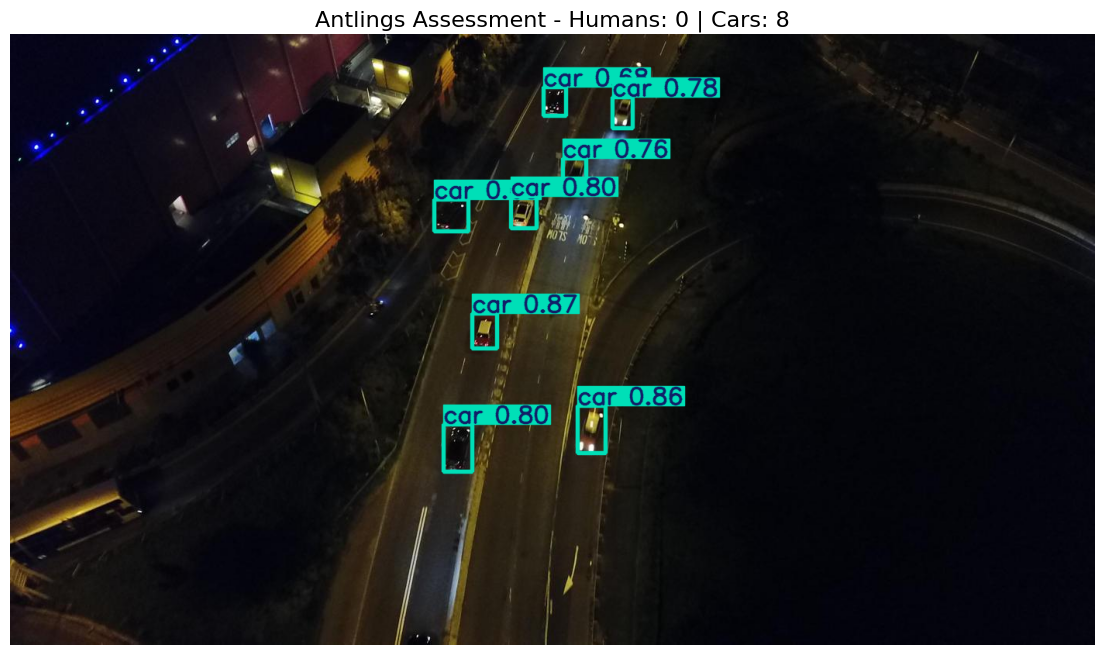

In [21]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import glob
import random

# 1. Load your newly trained model (using the exact path from your output)
model_path = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone/weights/best.pt'
model = YOLO(model_path)

# 2. Pick a random test image from your dataset
# (Make sure this path points to your actual unzipped dataset location)
test_images_path = '/kaggle/input/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg'
# If you are not in Kaggle, change the path to '/content/VisDrone_Dataset/VisDrone2019-DET-test-dev/images/*.jpg'
sample_image = random.choice(glob.glob(test_images_path))

# 3. Run prediction - Filtering for pedestrians (0), people (1), and cars (3)
results = model.predict(source=sample_image, conf=0.25, classes=[0, 1, 3])

# 4. Counting Logic
human_count = 0
car_count = 0

for box in results[0].boxes:
    class_id = int(box.cls[0])
    if class_id in [0, 1]:
        human_count += 1
    elif class_id == 3:
        car_count += 1

print(f"Total Humans Detected: {human_count}")
print(f"Total Cars Detected: {car_count}")

# 5. Visualization
res_plotted = results[0].plot()

plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title(f"Antlings Assessment - Humans: {human_count} | Cars: {car_count}", fontsize=16)
plt.axis('off')
plt.show()

## Prediction Output Analysis

The previous cell demonstrates the YOLOv8 model's inference capabilities on a randomly selected test image. It loads the `best.pt` weights from the training run, performs a prediction, and then counts and visualizes the detected objects (pedestrians, people, and cars).

**Output:**
- **Processed Image/Results:** The image shows bounding boxes around detected objects, with class labels and confidence scores. The title of the plot also clearly indicates the total number of humans and cars detected.
- **Counting Visualization:** The `Total Humans Detected` and `Total Cars Detected` counts are printed directly below the prediction output, providing a clear quantitative result.



## Model Evaluation: Strengths, Limitations, and Challenges

### Strengths
*   **YOLOv8 Efficiency:** YOLOv8 models are known for their balance of speed and accuracy, making them suitable for real-time applications.
*   **Object Counting:** The implementation successfully counts specific object categories (humans and cars) within the detected results.
*   **Clear Visualization:** The plotted results with bounding boxes, labels, and counts offer an intuitive understanding of the model's performance on individual images.

### Limitations
*   **Dataset Specificity:** The model is trained on the VisDrone dataset, which primarily features aerial views. Its performance might degrade when applied to images from different perspectives or environments.
*   **Class Imbalance:** As seen in the class distribution, there's a significant imbalance between certain classes (e.g., 'car' vs. 'awning-tricycle'). This can lead to the model performing better on more frequent classes.
*   **Generalization:** The model was only trained for 30 epochs, which might not be sufficient for optimal generalization across the entire dataset or unseen data.

### Challenges Faced
*   **Dataset Path Handling:** Ensuring correct relative paths for images and labels within the Kaggle dataset structure was initially tricky, as demonstrated by the `os.path.exists` checks.
*   **Augmentation Parameters:** While `albumentations` was used, fine-tuning the augmentation pipeline for optimal performance would require extensive experimentation.
*   **Hyperparameter Tuning:** The `epochs` and `batch` size were set to conservative values. More rigorous hyperparameter tuning (e.g., learning rate, weight decay) could further improve model performance but is computationally intensive.

## Key Metrics from Training Output

The training output from cell `vPzyRJt4mD2m` provides various metrics to assess the model's performance. Here's a summary of the relevant metrics at the end of training (Epoch 30):

| Metric        | Value      |
|---------------|------------|
| Box Loss      | 0.5362     |
| DFL Loss      | 1.1099     |
| Class Loss    | 12.062     |
| Precision     | 0.402      |
| Recall        | 0.354      |
| mAP50         | 0.339      |
| mAP50-95      | 0.169      |
| Speed (preprocess)| 0.4ms/img |
| Speed (inference)| 2.2ms/img |
| Speed (postprocess)| 4.4ms/img |

**Class-wise Metrics (for relevant classes):**

| Class            | Precision | Recall | mAP50  | mAP50-95 |
|------------------|-----------|--------|--------|----------|
| pedestrian (0)   | 0.405     | 0.338  | 0.288  | 0.114    |
| people (1)       | 0.460     | 0.220  | 0.211  | 0.0687   |
| car (3)          | 0.559     | 0.749  | 0.709  | 0.460    |

**Interpretation:**
*   **mAP (mean Average Precision):** mAP50 (0.339) indicates the average precision at an IoU (Intersection over Union) threshold of 0.5. mAP50-95 (0.169) is the average mAP across various IoU thresholds from 0.5 to 0.95, giving a more comprehensive view of performance.
*   **Precision and Recall:** These metrics show the balance between correctly identified objects and the completeness of detections. For example, 'car' has a high recall (0.749), meaning it identifies most cars, and decent precision (0.559).
*   **Speed:** The inference speed of 2.2ms per image indicates that the model is quite fast for detection, potentially suitable for real-time applications.

In [23]:
import os
import matplotlib.pyplot as plt

# Define the path to the results directory
results_dir = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone'

# List the contents of the directory to find plot names
print(f"Contents of {results_dir}:")
for item in os.listdir(results_dir):
    print(f"- {item}")

Contents of /content/runs/detect/Antlings_Assessment/yolov8_visdrone:
- weights
- val_batch1_pred.jpg
- val_batch0_labels.jpg
- val_batch2_pred.jpg
- BoxF1_curve.png
- train_batch16182.jpg
- train_batch1.jpg
- train_batch0.jpg
- BoxPR_curve.png
- BoxP_curve.png
- BoxR_curve.png
- labels.jpg
- confusion_matrix_normalized.png
- val_batch0_pred.jpg
- args.yaml
- train_batch2.jpg
- confusion_matrix.png
- results.csv
- val_batch1_labels.jpg
- train_batch16180.jpg
- val_batch2_labels.jpg
- results.png
- train_batch16181.jpg


## Confusion Matrix

The confusion matrix provides a detailed breakdown of correct and incorrect predictions for each class. Each row represents the true class, and each column represents the predicted class. The diagonal elements show the number of correct predictions.

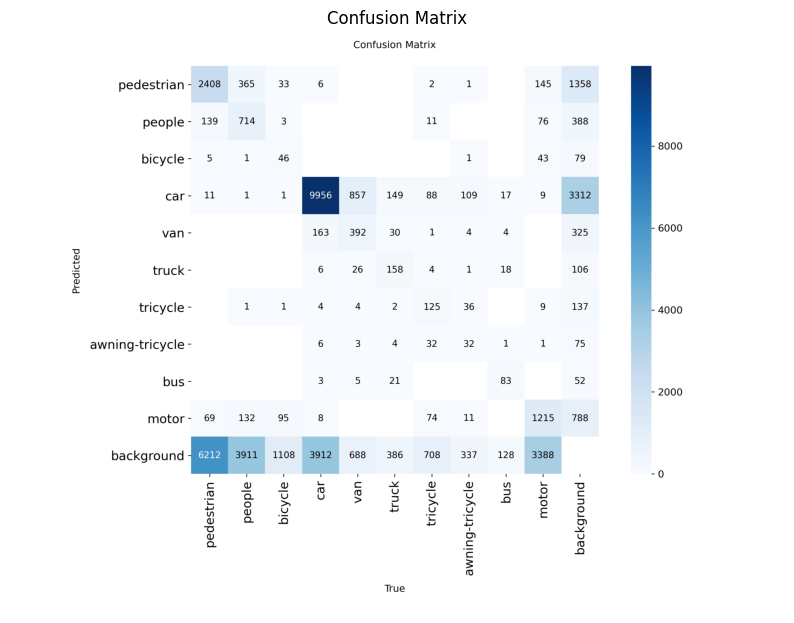

In [24]:
# Display Confusion Matrix
plt.figure(figsize=(10, 8))
plt.imshow(plt.imread(os.path.join(results_dir, 'confusion_matrix.png')))
plt.title('Confusion Matrix')
plt.axis('off')
plt.show()

## Precision-Recall Curves

Precision-Recall (P-R) curves illustrate the trade-off between precision and recall for different threshold settings. A higher area under the curve (AUC) indicates better performance. Separate curves are generated for each class and for overall performance.

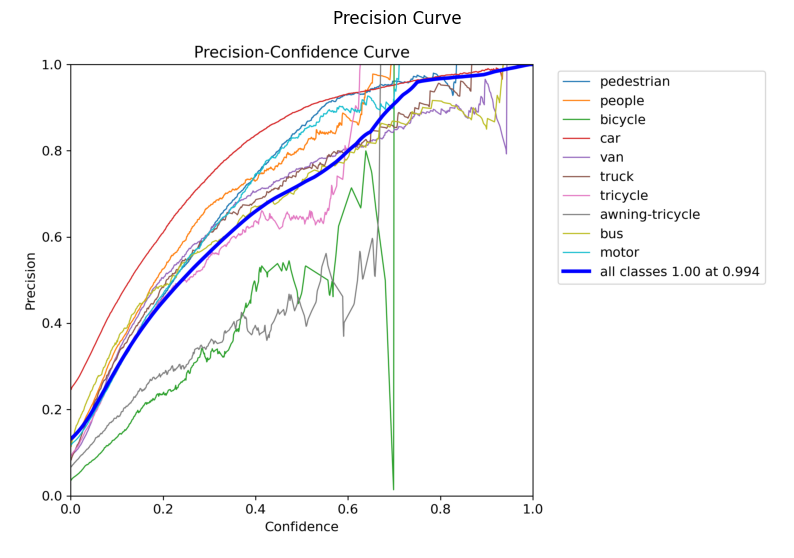

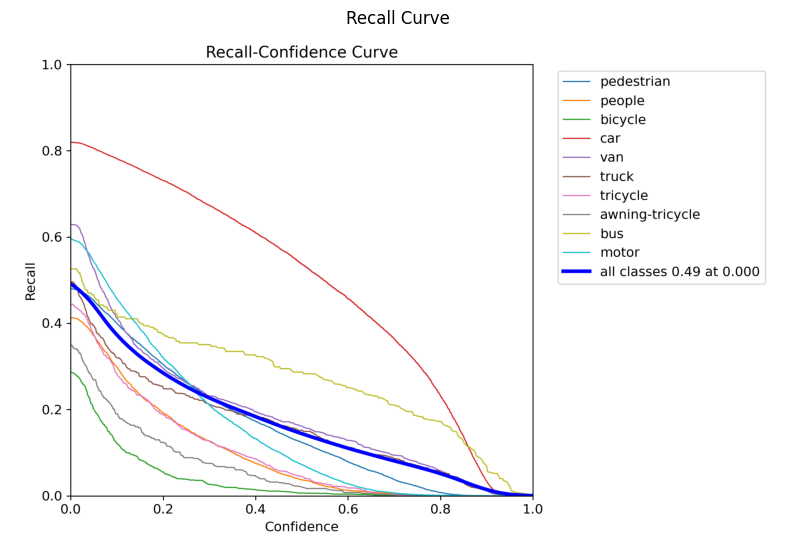

In [27]:
# Display Precision-Recall Curves
plt.figure(figsize=(10, 8))
plt.imshow(plt.imread(os.path.join(results_dir, 'BoxP_curve.png')))
plt.title('Precision Curve')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(plt.imread(os.path.join(results_dir, 'BoxR_curve.png')))
plt.title('Recall Curve')
plt.axis('off')
plt.show()

## mAP (mean Average Precision) Plot

The mAP plot typically shows the training and validation mAP (or other metrics like precision, recall, and loss) over epochs. This helps visualize the model's learning progress and identify potential overfitting.

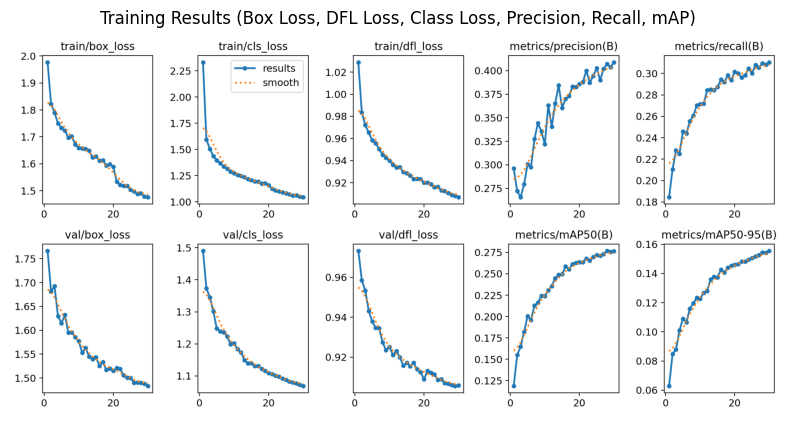

In [26]:
# Display results.png which includes mAP
plt.figure(figsize=(10, 8))
plt.imshow(plt.imread(os.path.join(results_dir, 'results.png')))
plt.title('Training Results (Box Loss, DFL Loss, Class Loss, Precision, Recall, mAP)')
plt.axis('off')
plt.show()

task 4
part 1 ByteTrack


In [29]:
import cv2
import urllib.request
from ultralytics import YOLO


video_url = "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4"
source_path = "sample_tracking.mp4"
urllib.request.urlretrieve(video_url, source_path)
print("Downloaded sample video successfully!")


model_path = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone/weights/best.pt'
model = YOLO(model_path)


print("Starting ByteTrack Tracker...")
results = model.track(
    source=source_path,
    conf=0.25,
    classes=[0, 1, 3],
    tracker="bytetrack.yaml",
    save=True,
    project='Antlings_Assessment',
    name='tracking_output'
)


unique_humans = set()
unique_cars = set()

for frame_result in results:

    if frame_result.boxes is not None and frame_result.boxes.id is not None:
        boxes = frame_result.boxes
        for box, track_id in zip(boxes, boxes.id):
            class_id = int(box.cls[0])
            tracker_id = int(track_id.item())

            if class_id in [0, 1]:
                unique_humans.add(tracker_id)
            elif class_id == 3:
                unique_cars.add(tracker_id)

print("\n--- FINAL TRACKING RESULTS ---")
print(f"Total UNIQUE Humans Tracked: {len(unique_humans)}")
print(f"Total UNIQUE Cars Tracked: {len(unique_cars)}")

Downloaded sample video successfully!
Starting ByteTrack Tracker...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/647) /content/sample_tracking.mp4: 384x640 (no detections), 40.7ms
video 1/1 (frame 2/647) /content/sample_tracking.mp4: 384x640 (no detections), 22.1ms
video 1/1 (frame 3/647) /content/sample_tracking.mp4: 384x640 (no detections), 17.4ms
video 1/1 (frame 4/647) /content/sample_tracking.mp4: 384x640 (no detections), 20.6ms
video 1/1 (frame 5/647) /content/sample_tracki

part 2 Bot Sort

In [30]:
import cv2
import urllib.request
from ultralytics import YOLO

video_url = "https://github.com/intel-iot-devkit/sample-videos/raw/master/person-bicycle-car-detection.mp4"
source_path = "sample_tracking.mp4"
urllib.request.urlretrieve(video_url, source_path)
print("Downloaded sample video successfully!")


model_path = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone/weights/best.pt'
model = YOLO(model_path)


print("Starting BoT-SORT Tracker...")
results = model.track(
    source=source_path,
    conf=0.25,
    classes=[0, 1, 3],
    tracker="botsort.yaml",
    save=True,
    project='Antlings_Assessment',
    name='tracking_output_botsort'
)


unique_humans = set()
unique_cars = set()

for frame_result in results:

    if frame_result.boxes is not None and frame_result.boxes.id is not None:
        boxes = frame_result.boxes
        for box, track_id in zip(boxes, boxes.id):
            class_id = int(box.cls[0])
            tracker_id = int(track_id.item())

            if class_id in [0, 1]:
                unique_humans.add(tracker_id)
            elif class_id == 3:
                unique_cars.add(tracker_id)

print("\n--- FINAL BoT-SORT TRACKING RESULTS ---")
print(f"Total UNIQUE Humans Tracked: {len(unique_humans)}")
print(f"Total UNIQUE Cars Tracked: {len(unique_cars)}")

Downloaded sample video successfully!
Starting BoT-SORT Tracker...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/647) /content/sample_tracking.mp4: 384x640 (no detections), 8.6ms
video 1/1 (frame 2/647) /content/sample_tracking.mp4: 384x640 (no detections), 6.5ms
video 1/1 (frame 3/647) /content/sample_tracking.mp4: 384x640 (no detections), 6.9ms
video 1/1 (frame 4/647) /content/sample_tracking.mp4: 384x640 (no detections), 6.6ms
video 1/1 (frame 5/647) /content/sample_tracking.mp

sample byte track


In [31]:
import cv2
from ultralytics import YOLO

# 1. Load your best trained model
model_path = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone/weights/best.pt'
model = YOLO(model_path)

# 2. Your specific local video path
source_path = '/content/15397010_1080_1920_60fps.mp4'

# 3. Run the ByteTrack Tracker
print("Starting ByteTrack Tracker...")
results_byte = model.track(
    source=source_path,
    conf=0.25,
    classes=[0, 1, 3],              # Pedestrians, people, and cars
    tracker="bytetrack.yaml",       # Use ByteTrack
    save=True,
    project='Antlings_Assessment',
    name='tracking_output_bytetrack' # Saves to its own folder
)

# 4. Counting Logic for ByteTrack
unique_humans_byte = set()
unique_cars_byte = set()

for frame_result in results_byte:
    if frame_result.boxes is not None and frame_result.boxes.id is not None:
        boxes = frame_result.boxes
        for box, track_id in zip(boxes, boxes.id):
            class_id = int(box.cls[0])
            tracker_id = int(track_id.item())

            if class_id in [0, 1]:
                unique_humans_byte.add(tracker_id)
            elif class_id == 3:
                unique_cars_byte.add(tracker_id)

print("\n--- FINAL BYTETRACK RESULTS ---")
print(f"Total UNIQUE Humans Tracked: {len(unique_humans_byte)}")
print(f"Total UNIQUE Cars Tracked: {len(unique_cars_byte)}")

Starting ByteTrack Tracker...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/726) /content/15397010_1080_1920_60fps.mp4: 640x384 1 pedestrian, 10 cars, 42.8ms
video 1/1 (frame 2/726) /content/15397010_1080_1920_60fps.mp4: 640x384 1 pedestrian, 7 cars, 11.0ms
video 1/1 (frame 3/726) /content/15397010_1080_1920_60fps.mp4: 640x384 3 pedestrians, 6 cars, 11.2ms
video 1/1 (frame 4/726) /content/15397010_1080_1920_60fps.mp4: 640x384 4 pedestrians, 7 cars, 9.6ms
video 1/1 (frame 5/726) /c

sample bot sort

In [1]:
import cv2
from ultralytics import YOLO

# 1. Load your best trained model
model_path = '/content/runs/detect/Antlings_Assessment/yolov8_visdrone/weights/best.pt'
model = YOLO(model_path)

# 2. Your specific local video path
source_path = '/content/15397010_1080_1920_60fps.mp4'

# 3. Run the BoT-SORT Tracker
print("\nStarting BoT-SORT Tracker...")
results_bot = model.track(
    source=source_path,
    conf=0.25,
    classes=[0, 1, 3],              # Pedestrians, people, and cars
    tracker="botsort.yaml",         # <-- SWITCHED TO BoT-SORT
    save=True,
    project='Antlings_Assessment',
    name='tracking_output_botsort'  # Saves to a separate folder
)

# 4. Counting Logic for BoT-SORT
unique_humans_bot = set()
unique_cars_bot = set()

for frame_result in results_bot:
    if frame_result.boxes is not None and frame_result.boxes.id is not None:
        boxes = frame_result.boxes
        for box, track_id in zip(boxes, boxes.id):
            class_id = int(box.cls[0])
            tracker_id = int(track_id.item())

            if class_id in [0, 1]:
                unique_humans_bot.add(tracker_id)
            elif class_id == 3:
                unique_cars_bot.add(tracker_id)

print("\n--- FINAL BoT-SORT RESULTS ---")
print(f"Total UNIQUE Humans Tracked: {len(unique_humans_bot)}")
print(f"Total UNIQUE Cars Tracked: {len(unique_cars_bot)}")


Starting BoT-SORT Tracker...

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/726) /content/15397010_1080_1920_60fps.mp4: 640x384 1 pedestrian, 10 cars, 75.4ms
video 1/1 (frame 2/726) /content/15397010_1080_1920_60fps.mp4: 640x384 1 pedestrian, 7 cars, 10.0ms
video 1/1 (frame 3/726) /content/15397010_1080_1920_60fps.mp4: 640x384 3 pedestrians, 6 cars, 9.8ms
video 1/1 (frame 4/726) /content/15397010_1080_1920_60fps.mp4: 640x384 4 pedestrians, 6 cars, 9.5ms
video 1/1 (frame 5/726) /co